# Selected Experiment Metrics Summary

This notebook summarizes the selected CE1 experiment results from `results/` and local `wandb/` folders. The February RBC baseline `rbc_baseline_vt_february` is included.

The CE1 README defines the primary and secondary metrics, but it does not define one official composite score. This notebook therefore shows four views side by side:

1. `overall_rank_score`: an equal-weight average of category rank scores across all major primary and secondary categories.
2. `primary_rank_score`: an equal-weight average of the three primary target categories only.
3. single-objective secondary tables: each secondary objective is ranked on its own, especially for metrics like Fairness that are not ideal to collapse into one recommended score.
4. `recommended_rank_score`: a more defensible custom composite that keeps the three primary categories dominant and only adds a small weight for a few operational secondary metrics.

Recommended composite formula:

`recommended_rank_score = 0.25 * rank(primary_load_cv_rmse_pct) + 0.25 * rank(|primary_load_nmbe_pct|) + 0.25 * average_rank(Thermal Comfort) + 0.10 * rank(site_energy_change) + 0.10 * average_rank(peak_demand metrics) + 0.05 * rank(system_ramping)`

Thermal Comfort is represented by these four values:

- `primary_comfort_exceedance_pct`
- `primary_comfort_exceedance_hours_total`
- `primary_comfort_exceedance_hours_mean`
- `primary_comfort_exceedance_hours_max`

Fairness is kept in the single-objective secondary tables because it is inherently multi-dimensional (`gini`, `entropy`, `max_share_pct`) and is not ideal to force into the recommended composite.


In [1]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, Markdown, display

pd.set_option('display.max_colwidth', 260)
pd.set_option('display.width', 360)
pd.set_option('display.max_columns', 120)
display(HTML('''
<style>
.dataframe td, .dataframe th { max-width: 1200px; }
.dataframe td { white-space: normal; word-break: break-word; }
</style>
'''))

REPO_DIR = Path.cwd()
if not (REPO_DIR / 'results').exists():
    REPO_DIR = REPO_DIR.parent

if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

import tools.summarize_selected_experiment_metrics as summary_mod
summary_mod = importlib.reload(summary_mod)

MARKDOWN_COLUMNS = summary_mod.MARKDOWN_COLUMNS
SELECTED_EXPERIMENTS = summary_mod.SELECTED_EXPERIMENTS
SUMMARY_COLUMNS = summary_mod.SUMMARY_COLUMNS
SECONDARY_OBJECTIVE_CATEGORIES = summary_mod.SECONDARY_OBJECTIVE_CATEGORIES
_build_ranked_tables = summary_mod._build_ranked_tables
_build_row = summary_mod._build_row
_write_markdown_table = summary_mod._write_markdown_table
_write_secondary_markdown = summary_mod._write_secondary_markdown

OUTPUT_ROOT = REPO_DIR / 'experiment_metric_summary'
WANDB_ROOT = REPO_DIR / 'wandb'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print(f'Repo: {REPO_DIR}')
print(f'Output: {OUTPUT_ROOT}')


Repo: /home/yue/EthanZhu/annex96_common_exercise_1
Output: /home/yue/EthanZhu/annex96_common_exercise_1/experiment_metric_summary


## Selected Experiments

In [2]:
pd.DataFrame({'experiment': SELECTED_EXPERIMENTS})

,experiment
0,rbc_baseline_vt_february
1,mappo_grouped_comm_v2_vt_500_final2
2,mappo_grouped_comm_weighted_a055_b045_vt_500_final2
3,mappo_grouped_comm_weighted_a090_b010_vt_500_final2
4,mappo_grouped_comm_weighted_default_vt_500_final2
...,...
89,mappo_grouped_tarmac_soft_router_twostage_3f_expert_routeronly500_temp05_prior1_vt_500_seed3
90,mappo_grouped_vt_500_final3
91,mappo_standard_vt_500_final3
92,rllib_independent_ppo_vt_80_final2


## Build Summary Tables

In [3]:
rows = [_build_row(experiment, WANDB_ROOT) for experiment in SELECTED_EXPERIMENTS]
tables = _build_ranked_tables(pd.DataFrame(rows))

ordered_columns = SUMMARY_COLUMNS + [column for column in tables['full'].columns if column not in SUMMARY_COLUMNS]

def order_columns(frame):
    frame_columns = ordered_columns + [column for column in frame.columns if column not in ordered_columns]
    return frame.loc[:, [column for column in frame_columns if column in frame.columns]].copy()

df = order_columns(tables['full'])
overall_df = order_columns(tables['overall'])
primary_only_df = order_columns(tables['primary_only'])
recommended_df = order_columns(tables['recommended'])
secondary_tables = {name: order_columns(frame) for name, frame in tables['secondary'].items()}

full_csv = OUTPUT_ROOT / 'selected_experiment_metrics_full.csv'
report_csv = OUTPUT_ROOT / 'selected_experiment_metrics_report_table.csv'
report_md = OUTPUT_ROOT / 'selected_experiment_metrics_report_table.md'
primary_csv = OUTPUT_ROOT / 'selected_experiment_metrics_primary_only_table.csv'
primary_md = OUTPUT_ROOT / 'selected_experiment_metrics_primary_only_table.md'
recommended_csv = OUTPUT_ROOT / 'selected_experiment_metrics_recommended_table.csv'
recommended_md = OUTPUT_ROOT / 'selected_experiment_metrics_recommended_table.md'
secondary_csv = OUTPUT_ROOT / 'selected_experiment_metrics_secondary_objective_ranks.csv'
secondary_md = OUTPUT_ROOT / 'selected_experiment_metrics_secondary_objective_tables.md'

df.to_csv(full_csv, index=False)
overall_df.to_csv(report_csv, index=False)
primary_only_df.to_csv(primary_csv, index=False)
recommended_df.to_csv(recommended_csv, index=False)
pd.concat([frame.assign(secondary_objective=name) for name, frame in secondary_tables.items()], ignore_index=True).to_csv(secondary_csv, index=False)

_write_markdown_table(report_md, overall_df, MARKDOWN_COLUMNS)
_write_markdown_table(primary_md, primary_only_df, [
    'primary_rank',
    'experiment',
    'seed',
    'primary_rank_score',
    'primary_load_cv_rmse_pct',
    'primary_load_nmbe_pct',
    'primary_abs_nmbe_pct',
    'primary_comfort_exceedance_pct',
    'primary_comfort_exceedance_hours_total',
    'primary_comfort_exceedance_hours_mean',
    'primary_comfort_exceedance_hours_max',
    'test_reward_sum',
    'wandb_run_id',
])
_write_markdown_table(recommended_md, recommended_df, [
    'recommended_rank',
    'experiment',
    'recommended_rank_score',
    'primary_load_cv_rmse_pct',
    'primary_load_nmbe_pct',
    'primary_comfort_exceedance_pct',
    'primary_comfort_exceedance_hours_total',
    'primary_comfort_exceedance_hours_mean',
    'primary_comfort_exceedance_hours_max',
    'secondary_site_energy_change_pct',
    'secondary_peak_demand_change_pct',
    'secondary_system_ramping_kw',
    'test_reward_sum',
    'wandb_run_id',
])
_write_secondary_markdown(secondary_md, secondary_tables)

print(f'Full metrics table -> {full_csv}')
print(f'Overall composite table -> {report_csv}')
print(f'Primary-only table -> {primary_csv}')
print(f'Recommended composite table -> {recommended_csv}')
print(f'Secondary single-objective tables -> {secondary_csv}')


Full metrics table -> /home/yue/EthanZhu/annex96_common_exercise_1/experiment_metric_summary/selected_experiment_metrics_full.csv
Overall composite table -> /home/yue/EthanZhu/annex96_common_exercise_1/experiment_metric_summary/selected_experiment_metrics_report_table.csv
Primary-only table -> /home/yue/EthanZhu/annex96_common_exercise_1/experiment_metric_summary/selected_experiment_metrics_primary_only_table.csv
Recommended composite table -> /home/yue/EthanZhu/annex96_common_exercise_1/experiment_metric_summary/selected_experiment_metrics_recommended_table.csv
Secondary single-objective tables -> /home/yue/EthanZhu/annex96_common_exercise_1/experiment_metric_summary/selected_experiment_metrics_secondary_objective_ranks.csv


## Overall Composite Report Table

In [4]:
overall_columns = [column for column in MARKDOWN_COLUMNS if column in overall_df.columns]
overall_view = overall_df[overall_columns].set_index('overall_rank')
display(overall_view)


,overall_rank_score,primary_rank,experiment,primary_rank_score,recommended_rank,recommended_rank_score,primary_load_cv_rmse_pct,primary_load_nmbe_pct,primary_comfort_exceedance_pct,primary_comfort_exceedance_hours_total,primary_comfort_exceedance_hours_mean,primary_comfort_exceedance_hours_max,test_reward_sum,kpi_electricity_consumption,kpi_carbon_emissions,kpi_cost,kpi_ramping,kpi_daily_peak,kpi_all_time_peak,kpi_load_factor,secondary_cost_change_pct,secondary_cost_absolute,secondary_cost_baseline,secondary_carbon_emissions_change_pct,secondary_carbon_emissions_kgco2e,secondary_carbon_emissions_baseline_kgco2e,secondary_site_energy_change_pct,secondary_site_total_energy_kwh,secondary_site_total_energy_baseline_kwh,secondary_peak_demand_kw,secondary_peak_demand_baseline_kw,secondary_peak_demand_change_pct,secondary_peak_demand_time,secondary_peak_demand_baseline_time,secondary_peak_to_valley_ratio_pct,secondary_peak_to_valley_ratio_baseline_pct,secondary_load_factor_pct,secondary_load_factor_baseline_pct,secondary_system_ramping_kw,secondary_system_ramping_baseline_kw,secondary_fairness_gini,secondary_fairness_entropy,secondary_fairness_max_share_pct,wandb_run_id
overall_rank,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
8,30.8704,1,mappo_grouped_tarmac_energy4f_agglomerative_linear_vt_500_seed0,9.3333,1,19.6000,48.1513,-0.0402,15.0298,2525.0,101.00,379.0,-4228.2296,1.2911,None,None,1.2167,1.1826,1.0968,0.8683,None,0.0,0.0,None,0.0,0.0,29.1085,71329.9526,71358.6730,281.4377,269.2477,4.5275,D03 09:00,D03 09:00,1142.9106,215.9844,62.2135,72.7119,465.1603,201.7081,0.1571,0.9881,6.4265,2eg6m7vy
4,28.5741,2,mappo_grouped_tarmac_hybrid_agglomerative_3f_I_no_capacity_comfort_vt_500_seed0,18.6667,2,20.8000,48.5971,0.9971,15.8631,2665.0,106.60,360.0,-4256.8807,1.3058,None,None,1.2321,1.2034,1.0308,0.8810,None,0.0,0.0,None,0.0,0.0,30.5843,72023.7100,71312.6537,248.7273,264.7802,-6.0627,D02 23:00,D03 09:00,2143.3272,214.1044,62.0355,73.1857,455.8599,197.6137,0.1359,0.9910,6.5702,NaN
7,30.5926,11,rllib_independent_ppo_vt_80_final2,25.5000,3,23.1750,49.7644,1.2449,13.7440,2309.0,92.36,314.0,-3833.2359,1.2681,None,None,0.9790,1.1643,1.0459,0.8308,None,0.0,0.0,None,0.0,0.0,26.8114,72588.6488,71696.0824,256.3215,263.4027,-2.6884,D02 20:00,D03 09:00,1375.0445,214.6351,64.1065,72.8875,372.0552,199.6006,0.2888,0.9540,13.6178,ymjhdsaz
10,31.4815,9,mappo_grouped_tarmac_soft_router_twostage_3f_expert_routeronly500_temp05_prior1_vt_500_seed3,24.8333,4,23.7250,48.8184,-1.9154,15.0595,2530.0,101.20,376.0,-4062.0475,1.2904,None,None,1.2256,1.1849,1.0421,0.9085,None,0.0,0.0,None,0.0,0.0,29.0364,69497.9411,70855.0644,250.0924,265.0976,-5.6602,D03 05:00,D03 09:00,1408.4766,214.4987,60.4918,72.7285,461.2106,201.5470,0.1463,0.9893,6.6776,mv9w3dcn
1,23.0000,15,mappo_grouped_tarmac_hybrid_agglomerative_3f_C_heatmax_nslmean_vt_500_seed0,28.8333,5,24.3750,47.2344,-2.3607,17.2262,2894.0,115.76,474.0,-5073.6016,1.2608,None,None,1.1895,1.1753,1.0284,0.8931,None,0.0,0.0,None,0.0,0.0,26.0771,69072.3366,70742.3181,251.1344,261.3754,-3.9181,D03 05:00,D03 09:00,1032.8623,214.9416,61.2851,72.9186,442.9909,199.5849,0.1294,0.9915,5.6771,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,64.5185,83,mappo_standard_vt_500_final3,69.8333,90,72.8250,53.2983,5.2886,21.0833,3542.0,141.68,625.0,-5768.7278,1.3408,None,None,1.3307,1.2795,1.2137,0.9087,None,0.0,0.0,None,0.0,0.0,34.0840,75759.2650,71953.9173,299.3276,273.9167,9.2769,D03 07:00,D03 09:00,1248.7509,216.7890,60.7545,72.8578,506.4240,203.9963,0.1507,0.9891,6.3089,tdxkwwwt
84,60.4444,91,mappo_grouped_powernet_global_kmeans_operational_profile_vt_500_final,78.1667,91,73.9750,53.3941,3.7482,31.3571,5268.0,210.72,628.0,-8419.4369,1.3367,None,None,1.4462,1.2248,1.1008,0.8750,None,0.0,0.0,None,0.0,0.0,33.6674,74445.9331,71756.3514,259.3820,260.8429,-0.5601,D03 07:00,D03 09:00,938.6072,213.6321,62

## Primary-Only Ranking

In [5]:
primary_columns = [
    'primary_rank',
    'experiment',
    'seed',
    'primary_rank_score',
    'primary_load_cv_rmse_pct',
    'primary_load_nmbe_pct',
    'primary_abs_nmbe_pct',
    'primary_comfort_exceedance_pct',
    'primary_comfort_exceedance_hours_total',
    'primary_comfort_exceedance_hours_mean',
    'primary_comfort_exceedance_hours_max',
    'test_reward_sum',
    'wandb_run_id',
]
primary_view = primary_only_df[[column for column in primary_columns if column in primary_only_df.columns]].set_index('primary_rank')
display(primary_view)


,experiment,seed,primary_rank_score,primary_load_cv_rmse_pct,primary_load_nmbe_pct,primary_abs_nmbe_pct,primary_comfort_exceedance_pct,primary_comfort_exceedance_hours_total,primary_comfort_exceedance_hours_mean,primary_comfort_exceedance_hours_max,test_reward_sum,wandb_run_id
primary_rank,,,,,,,,,,,,
1,mappo_grouped_tarmac_energy4f_agglomerative_linear_vt_500_seed0,0.0,9.3333,48.1513,-0.0402,0.0402,15.0298,2525.0,101.00,379.0,-4228.2296,2eg6m7vy
2,mappo_grouped_tarmac_hybrid_agglomerative_3f_I_no_capacity_comfort_vt_500_seed0,0.0,18.6667,48.5971,0.9971,0.9971,15.8631,2665.0,106.60,360.0,-4256.8807,NaN
3,mappo_grouped_tarmac_hybrid_agglomerative_capacity_load_3f_linear_vt_500_final,42.0,19.1667,44.6221,-0.5740,0.5740,20.0655,3371.0,134.84,493.0,-5202.0166,pbmpfob6
4,mappo_grouped_tarmac_soft_router_twostage_3f_expert_routeronly500_temp05_prior1_vt_500_seed1,1.0,21.5000,48.0599,0.3554,0.3554,19.7798,3323.0,132.92,521.0,-5336.1230,6p3mny0l
5,mappo_grouped_tarmac_soft_router_twostage_3f_expert_routeronly500_temp05_prior1_vt_500_final,42.0,21.5833,45.9919,-1.2210,1.2210,19.1726,3221.0,128.84,499.0,-4959.2942,1h3tjb6p
...,...,...,...,...,...,...,...,...,...,...,...,...
90,mappo_grouped_tarmac_hybrid_agglomerative_3f_D_heatmean_nslmax_vt_500_seed2,2.0,77.5833,57.3398,5.5003,5.5003,23.2560,3907.0,156.28,560.0,-7421.1642,NaN
91,mappo_grouped_powernet_global_kmeans_operational_profile_vt_500_final,42.0,78.1667,53.3941,3.7482,3.7482,31.3571,5268.0,210.72,628.0,-8419.4369,lgvfsd39
92,mappo_grouped_powernet_global_agglomerative_static_operational_vt_500_final,42.0,79.0000,58.8911,-2.8959,2.8959,39.4464,6627.0,265.08,578.0,-11970.8511,vvdl9q9v


## Secondary Single-Objective Tables

In [6]:
secondary_display_columns = {
    'fairness': [
        'experiment',
        'fairness_rank_score',
        'secondary_fairness_gini',
        'secondary_fairness_entropy',
        'secondary_fairness_max_share_pct',
    ],
    'site_energy': [
        'experiment',
        'site_energy_rank_score',
        'secondary_site_energy_change_pct',
        'secondary_site_total_energy_kwh',
        'secondary_site_total_energy_baseline_kwh',
    ],
    'peak_demand': [
        'experiment',
        'peak_demand_rank_score',
        'secondary_peak_demand_kw',
        'secondary_peak_demand_baseline_kw',
        'secondary_peak_demand_change_pct',
        'secondary_peak_demand_time',
        'secondary_peak_demand_baseline_time',
    ],
    'peak_to_valley_ratio': [
        'experiment',
        'peak_to_valley_ratio_rank_score',
        'secondary_peak_to_valley_ratio_pct',
        'secondary_peak_to_valley_ratio_baseline_pct',
    ],
    'load_factor': [
        'experiment',
        'load_factor_rank_score',
        'secondary_load_factor_pct',
        'secondary_load_factor_baseline_pct',
    ],
    'system_ramping': [
        'experiment',
        'system_ramping_rank_score',
        'secondary_system_ramping_kw',
        'secondary_system_ramping_baseline_kw',
    ],
}

for category in SECONDARY_OBJECTIVE_CATEGORIES:
    table = secondary_tables[category]
    rank_column = f'{category}_rank'
    display(Markdown(f"### {category.replace('_', ' ').title()}"))
    view_columns = [rank_column] + [column for column in secondary_display_columns[category] if column in table.columns]
    display(table[view_columns].set_index(rank_column))


### Fairness

,experiment,fairness_rank_score,secondary_fairness_gini,secondary_fairness_entropy,secondary_fairness_max_share_pct
fairness_rank,,,,,
1,mappo_grouped_tarmac_hybrid_agglomerative_3f_B_hvac_nslmean_vt_500_seed2,3.0000,0.1015,0.9946,5.6881
2,mappo_grouped_tarmac_hybrid_agglomerative_3f_C_heatmax_nslmean_vt_500_seed1,3.3333,0.1197,0.9930,5.6584
3,mappo_grouped_tarmac_hybrid_vt_500_final2,3.3333,0.1207,0.9931,5.6578
4,mappo_grouped_tarmac_hybrid_agglomerative_3f_B_hvac_nslmean_vt_500_seed0,5.0000,0.1200,0.9932,5.8603
5,mappo_grouped_vt_500_final3,5.3333,0.1263,0.9919,5.5315
...,...,...,...,...,...
90,mappo_grouped_tarmac_hybrid_agglomerative_3f_H_heatmean_tempstd_vt_500_seed0,90.0000,0.2632,0.9596,12.3529
91,rllib_independent_ppo_vt_80_final2,91.3333,0.2888,0.9540,13.6178
92,rllib_sac_vt_500_final2,91.6667,0.2983,0.9529,13.0155


### Site Energy

,experiment,site_energy_rank_score,secondary_site_energy_change_pct,secondary_site_total_energy_kwh,secondary_site_total_energy_baseline_kwh
site_energy_rank,,,,,
1,rllib_sac_vt_500_final2,1.0,13.7496,62179.0289,68274.9805
2,mappo_grouped_powernet_global_gmm_static_operational_vt_500_final,2.0,17.8630,60433.2956,69105.6291
3,mappo_grouped_commnet_vt_500_final2,3.0,22.1867,63717.3844,69342.8326
4,mappo_grouped_tarmac_soft_router_three_stage_shared_3f_vt_1500_seed42,4.0,22.8040,64707.5076,69938.9708
5,mappo_grouped_tarmac_soft_router_agglomerative_5f_capacity_router_temp05_vt_500_final,5.0,23.6862,65970.6685,70071.2958
...,...,...,...,...,...
90,mappo_grouped_powernet_global_agglomerative_capacity_load_3f_vt_500_final,90.0,34.9260,73935.2605,71822.0673
91,mappo_grouped_tarmac_hybrid_agglomerative_3f_B_hvac_nslmean_vt_500_seed0,91.0,35.8993,73116.4164,71599.8969
92,mappo_grouped_powernet_global_gmm_capacity_load_5f_vt_500_final,92.0,36.3229,75370.2500,71822.2461


### Peak Demand

...

,experiment,peak_to_valley_ratio_rank_score,secondary_peak_to_valley_ratio_pct,secondary_peak_to_valley_ratio_baseline_pct
peak_to_valley_ratio_rank,,,,
1,mappo_grouped_tarmac_hybrid_agglomerative_3f_B_hvac_nslmean_vt_500_seed0,1.0,370.4317,216.6652
2,mappo_grouped_tarmac_soft_router_three_stage_full_expert_3f_vt_seed42,2.0,487.0061,213.3744
3,mappo_grouped_tarmac_hybrid_agglomerative_capacity_load_5f_linear_vt_500_seed1,3.0,504.3222,214.5921
4,mappo_grouped_powernet_global_kmeans_static_extended_vt_500_final,4.0,514.2773,216.4550
5,mappo_grouped_tarmac_hybrid_agglomerative_3f_C_heatmax_nslmean_vt_500_seed2,5.0,539.4254,213.8570
...,...,...,...,...
90,mappo_grouped_tarmac_soft_router_agglomerative_5f_capacity_router_vt_500_final,90.0,8234.1215,216.6908
91,mappo_grouped_tarmac_soft_router_twostage_3f_expert_freeze200_temp05_prior1_no_capacity_vt_500_final,91.0,22049.8073,213.4110
92,mappo_grouped_tarmac_hybrid_agglomerative_3f_H_heatmean_tempstd_vt_500_seed1,92.0,229996.2185,214.7606


### Load Factor

,experiment,load_factor_rank_score,secondary_load_factor_pct,secondary_load_factor_baseline_pct
load_factor_rank,,,,
1,rllib_sac_vt_500_final2,1.0,66.0553,73.2266
2,mappo_grouped_powernet_vt_500_final2,2.0,66.0403,72.8135
3,rllib_independent_ppo_vt_80_final2,3.0,64.1065,72.8875
4,mappo_grouped_powernet_global_vt_500_final2,4.0,63.9658,73.4827
5,mappo_grouped_tarmac_soft_router_full_expert_stable_heads_3f_vt_seed42,5.0,63.8885,73.0881
...,...,...,...,...
90,mappo_grouped_tarmac_soft_router_three_stage_shared_3f_vt_1500_seed42,90.0,57.0689,72.8032
91,mappo_grouped_powernet_global_agglomerative_static_operational_vt_500_final,91.0,56.6322,72.8539
92,mappo_grouped_dial_vt_500_final2,92.0,55.0135,73.2893


### System Ramping

,experiment,system_ramping_rank_score,secondary_system_ramping_kw,secondary_system_ramping_baseline_kw
system_ramping_rank,,,,
1,rllib_sac_vt_500_final2,1.0,353.4754,195.0542
2,rllib_independent_ppo_vt_80_final2,2.0,372.0552,199.6006
3,mappo_grouped_comm_weighted_default_vt_500_final2,3.0,429.0527,199.7816
4,mappo_grouped_tarmac_hybrid_agglomerative_3f_G_heatmean_comfort_vt_500_seed2,4.0,441.6196,199.5274
5,mappo_grouped_commnet_vt_500_final2,5.0,441.7838,196.3430
...,...,...,...,...
90,mappo_grouped_tarmac_hybrid_agglomerative_3f_D_heatmean_nslmax_vt_500_seed2,90.0,574.1005,200.8280
91,mappo_grouped_tarmac_hybrid_agglomerative_3f_E_hvac_nslmax_vt_500_seed2,91.0,591.5482,199.3505
92,mappo_grouped_tarmac_energy4f_agglomerative_linear_vt_500_seed42,92.0,604.3704,197.7650


## Recommended Composite Ranking

In [7]:
recommended_columns = [
    'recommended_rank',
    'experiment',
    'recommended_rank_score',
    'primary_load_cv_rmse_pct',
    'primary_load_nmbe_pct',
    'primary_comfort_exceedance_pct',
    'primary_comfort_exceedance_hours_total',
    'primary_comfort_exceedance_hours_mean',
    'primary_comfort_exceedance_hours_max',
    'secondary_site_energy_change_pct',
    'secondary_peak_demand_change_pct',
    'secondary_system_ramping_kw',
    'test_reward_sum',
    'wandb_run_id',
]
recommended_view = recommended_df[[column for column in recommended_columns if column in recommended_df.columns]].set_index('recommended_rank')
display(recommended_view)


,experiment,recommended_rank_score,primary_load_cv_rmse_pct,primary_load_nmbe_pct,primary_comfort_exceedance_pct,primary_comfort_exceedance_hours_total,primary_comfort_exceedance_hours_mean,primary_comfort_exceedance_hours_max,secondary_site_energy_change_pct,secondary_peak_demand_change_pct,secondary_system_ramping_kw,test_reward_sum,wandb_run_id
recommended_rank,,,,,,,,,,,,,
1,mappo_grouped_tarmac_energy4f_agglomerative_linear_vt_500_seed0,19.6000,48.1513,-0.0402,15.0298,2525.0,101.00,379.0,29.1085,4.5275,465.1603,-4228.2296,2eg6m7vy
2,mappo_grouped_tarmac_hybrid_agglomerative_3f_I_no_capacity_comfort_vt_500_seed0,20.8000,48.5971,0.9971,15.8631,2665.0,106.60,360.0,30.5843,-6.0627,455.8599,-4256.8807,NaN
3,rllib_independent_ppo_vt_80_final2,23.1750,49.7644,1.2449,13.7440,2309.0,92.36,314.0,26.8114,-2.6884,372.0552,-3833.2359,ymjhdsaz
4,mappo_grouped_tarmac_soft_router_twostage_3f_expert_routeronly500_temp05_prior1_vt_500_seed3,23.7250,48.8184,-1.9154,15.0595,2530.0,101.20,376.0,29.0364,-5.6602,461.2106,-4062.0475,mv9w3dcn
5,mappo_grouped_tarmac_hybrid_agglomerative_3f_C_heatmax_nslmean_vt_500_seed0,24.3750,47.2344,-2.3607,17.2262,2894.0,115.76,474.0,26.0771,-3.9181,442.9909,-5073.6016,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,mappo_standard_vt_500_final3,72.8250,53.2983,5.2886,21.0833,3542.0,141.68,625.0,34.0840,9.2769,506.4240,-5768.7278,tdxkwwwt
91,mappo_grouped_powernet_global_kmeans_operational_profile_vt_500_final,73.9750,53.3941,3.7482,31.3571,5268.0,210.72,628.0,33.6674,-0.5601,546.3703,-8419.4369,lgvfsd39
92,rbc_baseline_vt_february,77.9625,138.2660,109.3673,68.3458,11465.0,458.60,586.0,29.4738,-8.4421,NaN,NaN,NaN


## Primary Metrics Plots

Plot -> /home/yue/EthanZhu/annex96_common_exercise_1/experiment_metric_summary/selected_experiment_primary_metrics.png


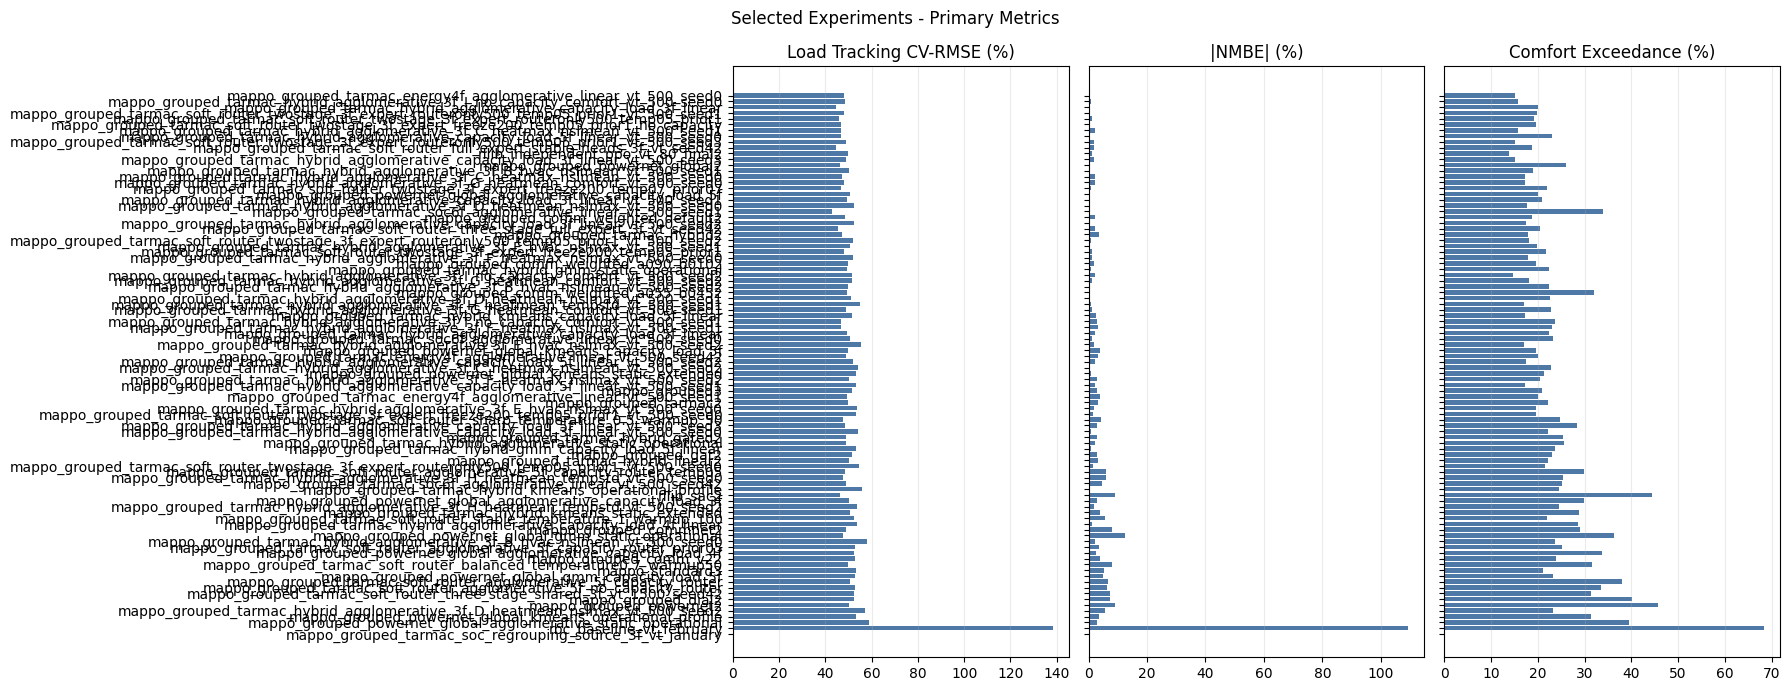

In [8]:
plot_df = primary_only_df.sort_values('primary_rank').copy()
labels = plot_df['experiment'].str.replace('_vt_500_final', '', regex=False)
labels = labels.str.replace('_vt_42_final', '', regex=False)
labels = labels.str.replace('_vt_50_final', '', regex=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)

metrics = [
    ('primary_load_cv_rmse_pct', 'Load Tracking CV-RMSE (%)'),
    ('primary_abs_nmbe_pct', '|NMBE| (%)'),
    ('primary_comfort_exceedance_pct', 'Comfort Exceedance (%)'),
]

for ax, (column, title) in zip(axes, metrics):
    ax.barh(labels, plot_df[column], color='#4e79a7')
    ax.invert_yaxis()
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.25)

fig.suptitle('Selected Experiments - Primary Metrics')
fig.tight_layout()

plot_path = OUTPUT_ROOT / 'selected_experiment_primary_metrics.png'
fig.savefig(plot_path, dpi=180, bbox_inches='tight')
print(f'Plot -> {plot_path}')
plt.show()


## Secondary Metrics Plots

Plot -> /home/yue/EthanZhu/annex96_common_exercise_1/experiment_metric_summary/selected_experiment_secondary_metrics.png


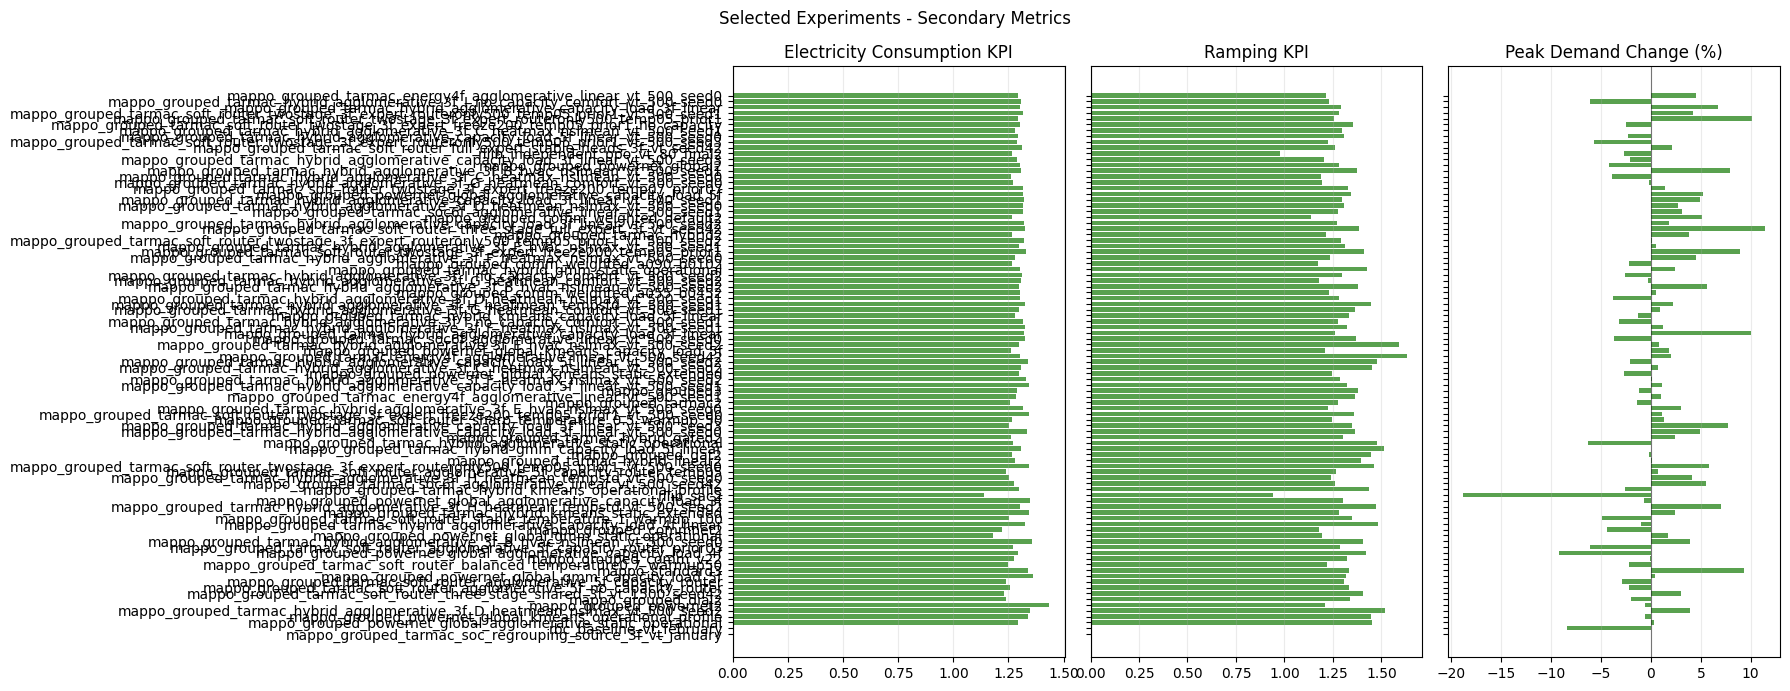

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)

secondary_metrics = [
    ('kpi_electricity_consumption', 'Electricity Consumption KPI'),
    ('kpi_ramping', 'Ramping KPI'),
    ('secondary_peak_demand_change_pct', 'Peak Demand Change (%)'),
]

for ax, (column, title) in zip(axes, secondary_metrics):
    ax.barh(labels, plot_df[column], color='#59a14f')
    ax.axvline(0, color='black', linewidth=0.8, alpha=0.5)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.25)

fig.suptitle('Selected Experiments - Secondary Metrics')
fig.tight_layout()

plot_path = OUTPUT_ROOT / 'selected_experiment_secondary_metrics.png'
fig.savefig(plot_path, dpi=180, bbox_inches='tight')
print(f'Plot -> {plot_path}')
plt.show()


## W&B Match Check

In [10]:
wandb_check_columns = ['experiment', 'wandb_run_id', 'wandb_started_at', 'wandb_program', 'wandb_run_dir']
display(df[[column for column in wandb_check_columns if column in df.columns]])


,experiment,wandb_run_id,wandb_started_at,wandb_program,wandb_run_dir
0,mappo_grouped_tarmac_energy4f_agglomerative_linear_vt_500_seed0,2eg6m7vy,2026-07-26T10:45:54.571372Z,-m mappo_grouped_tarmac_soc_regrouping.train,wandb/run-20260726_204554-2eg6m7vy
1,mappo_grouped_tarmac_hybrid_agglomerative_3f_I_no_capacity_comfort_vt_500_seed0,NaN,NaN,NaN,NaN
2,rllib_independent_ppo_vt_80_final2,ymjhdsaz,2026-04-24T06:16:20.110858Z,-m rllib_independent_ppo.train,wandb/run-20260424_141620-ymjhdsaz
3,mappo_grouped_tarmac_soft_router_twostage_3f_expert_routeronly500_temp05_prior1_vt_500_seed3,mv9w3dcn,2026-07-22T12:17:08.256936Z,-m mappo_grouped_tarmac_soft_router.train,wandb/run-20260722_221708-mv9w3dcn
4,mappo_grouped_tarmac_hybrid_agglomerative_3f_C_heatmax_nslmean_vt_500_seed0,NaN,NaN,NaN,NaN
...,...,...,...,...,...
89,mappo_standard_vt_500_final3,tdxkwwwt,2026-04-24T06:20:39.741565Z,-m mappo_standard.train,wandb/run-20260424_162039-tdxkwwwt
90,mappo_grouped_powernet_global_kmeans_operational_profile_vt_500_final,lgvfsd39,2026-06-23T14:06:53.554939Z,-m mappo_grouped_powernet_global_grouping.train,wandb/run-20260624_000653-lgvfsd39
91,rbc_baseline_vt_february,NaN,NaN,NaN,NaN
92,mappo_grouped_tarmac_hybrid_agglomerative_3f_D_heatmean_nslmax_vt_500_seed2,NaN,NaN,NaN,NaN
